# AAVAIL — Singapore Churn: End-to-End Analysis

**One notebook, full pipeline** — from raw, incomplete data to a stakeholder recommendation.

**Business question.** Singapore churns far worse than the US. Where is the leak, and what
should AAVAIL do about it?

**Contents**
1. Setup
2. Missing data — extent & data-quality checks
3. Missing data — mechanism (MCAR vs MAR)
4. Imputation (mechanism-specific) + validation
5. Market visualization (US vs Singapore)
6. Churn framing + market-gap test (χ² · Cramér's V)
7. Singapore drill-down (Mann–Whitney U · Cohen's d · χ²)
8. Interpretable model — logistic regression (odds ratios)
9. Predictive model — random forest (ROC-AUC · permutation importance)
10. Segmentation — K-means
11. Findings, caveats & next steps

> Runs top-to-bottom from the raw `aavail-data-visualization.csv`; no other files required.

## 1 · Setup

In [39]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib as mpl

RNG = np.random.default_rng(42)                 # reproducible randomness
df = pd.read_csv('data/aavail-data-visualization.csv')
orig = df.copy()                                # pristine reference for validation
print("shape:", df.shape)
df['market'] = df['country_name'].map({'united_states': 'United States',
                                        'singapore': 'Singapore'})
df.head()

shape: (1000, 7)


,customer_id,country_name,age,customer_name,is_subscriber,subscriber_type,num_streams,market
0,1,united_states,21.0,Kasen Todd,True,aavail_premium,23.0,United States
1,2,singapore,31.0,Ensley Garza,False,NaN,12.0,Singapore
2,3,united_states,22.0,Lillian Carey,False,aavail_premium,22.0,United States
3,4,united_states,21.0,Beau Christensen,True,aavail_basic,19.0,United States
4,5,singapore,22.0,Ernesto Gibson,True,aavail_premium,23.0,Singapore


In [7]:
# shared palette + style
INK, US, SG, MUT = '#16233A', '#2C6E8F', '#D64C3C', '#8A94A6'
PLAN_ORDER = ['aavail_basic', 'aavail_premium', 'aavail_unlimited']
PLAN_LABELS = ['Basic', 'Premium', 'Unlimited']
sns.set_style('whitegrid')
mpl.rcParams.update({'font.size': 12, 'axes.edgecolor': MUT,
                     'axes.titleweight': 'bold', 'figure.autolayout': True,
                     'axes.spines.top': False, 'axes.spines.right': False})

## 2 · Missing data — extent & quality

Count nulls per column, then confirm nothing is hiding as duplicates, impossible ages, or
bad stream counts.

In [8]:
miss = df.isna().sum()
print(pd.DataFrame({'missing': miss, 'pct': (miss/len(df)*100).round(2)})[miss > 0])

print("\nDuplicate ids:", df['customer_id'].duplicated().sum(),
      "| duplicate names:", df['customer_name'].duplicated().sum())
print("Age range:", df['age'].min(), "-", df['age'].max(),
      "| streams range:", df['num_streams'].min(), "-", df['num_streams'].max(),
      "| zero/neg streams:", ((df['num_streams'] <= 0).sum()))

                 missing  pct
subscriber_type       72  7.2
num_streams           46  4.6

Duplicate ids: 0 | duplicate names: 0
Age range: 14.0 - 57.0 | streams range: 1.0 - 29.0 | zero/neg streams: 0


Only **`subscriber_type` (7.2%)** and **`num_streams` (4.6%)** are missing. No duplicates,
no impossible values — the two null columns are the only fix needed.

## 3 · Missing data — mechanism

*Why* a value is missing decides *how* to fill it. We cross-tab each column's missingness
against the others to classify it (MCAR = unrelated to anything; MAR = depends on observed
columns).

In [9]:
st_missing = df['subscriber_type'].isna()
ns_missing = df['num_streams'].isna()
print("subscriber_type missing-rate by country:")
print(pd.crosstab(df['country_name'], st_missing, normalize='index').round(3))
print("\nnum_streams missing-rate by country:")
print(pd.crosstab(df['country_name'], ns_missing, normalize='index').round(3))
print("\nnum_streams missing-rate by plan:")
print(pd.crosstab(df['subscriber_type'], ns_missing, normalize='index').round(3))

subscriber_type missing-rate by country:
subscriber_type  False  True 
country_name                 
singapore        0.930  0.070
united_states    0.927  0.073

num_streams missing-rate by country:
num_streams    False  True 
country_name               
singapore      0.927  0.073
united_states  0.966  0.034

num_streams missing-rate by plan:
num_streams       False  True 
subscriber_type               
aavail_basic      0.926  0.074
aavail_premium    0.936  0.064
aavail_unlimited  1.000  0.000


- **`subscriber_type` ≈ MCAR** — flat missing rate across markets, unrelated to other fields.
- **`num_streams` ≈ MAR** — missing ~2× more in Singapore and **never** for Unlimited, so its
  missingness depends on observed columns. → impute *within* those groups.

## 4 · Imputation (mechanism-specific) + validation

- **`subscriber_type` (MCAR):** proportional fill — draw from each market's own observed plan
  mix, preserving the real distribution instead of collapsing to the mode. Done **first**
  because the next step groups by it.
- **`num_streams` (MAR):** median within `country × subscriber_type` — grouped for the MAR
  structure, median for robustness to the low-end tail.

In [10]:
# subscriber_type — proportional draw within country
for country, grp in df.groupby('country_name'):
    probs = grp['subscriber_type'].dropna().value_counts(normalize=True)
    mask = (df['country_name'] == country) & (df['subscriber_type'].isna())
    n = int(mask.sum())
    if n:
        df.loc[mask, 'subscriber_type'] = RNG.choice(probs.index.to_numpy(),
                                                      size=n, p=probs.to_numpy())

# num_streams — group median
grp_median = df.groupby(['country_name','subscriber_type'])['num_streams'].transform('median')
df['num_streams'] = df['num_streams'].fillna(grp_median).round().astype(int)

# validate
print("remaining nulls:", df.isna().sum().sum())
b = orig['subscriber_type'].value_counts(normalize=True).round(3)
a = df['subscriber_type'].value_counts(normalize=True).round(3)
print("\nplan mix before/after:\n", pd.DataFrame({'before': b, 'after': a}))
print("\nnum_streams mean before/after: %.2f / %.2f"
      % (orig['num_streams'].mean(), df['num_streams'].mean()))
df.to_csv('data/aavail-imputed.csv', index=False)

remaining nulls: 0

plan mix before/after:
                   before  after
subscriber_type                
aavail_basic       0.365  0.366
aavail_premium     0.337  0.340
aavail_unlimited   0.297  0.294

num_streams mean before/after: 17.78 / 17.78


No nulls remain, distributions shift < 0.3 pp — the fills are faithful. Cleaned file saved.

## 5 · Market visualization — US vs Singapore

Four panels on the cleaned data: market size, subscription rate, plan mix, engagement.

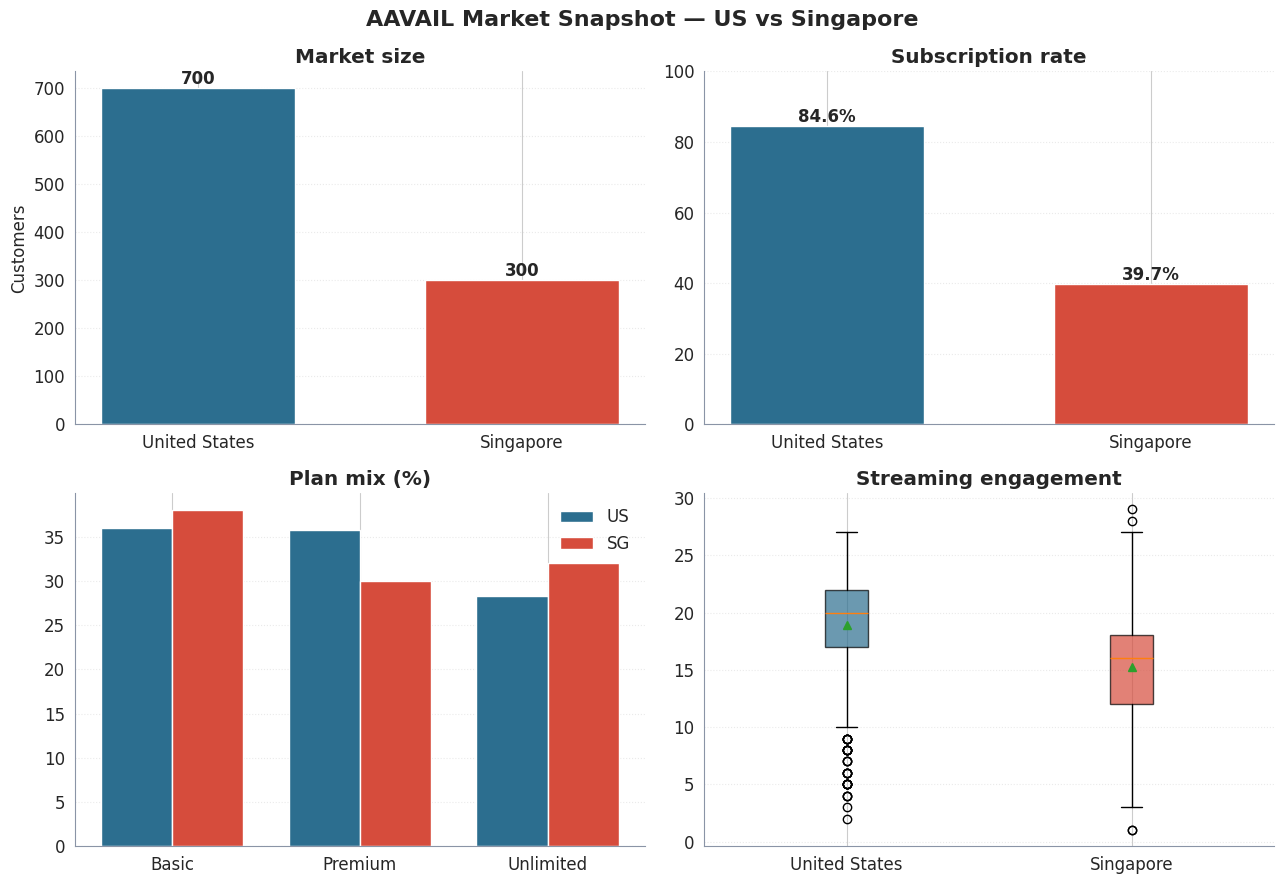

In [11]:
US, SG = 'united_states', 'singapore'
C_US, C_SG = '#2C6E8F', '#D64C3C'
lab = {US:'United States', SG:'Singapore'}
fig, ax = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('AAVAIL Market Snapshot — US vs Singapore', fontweight='bold', fontsize=16)

cnt = df['country_name'].value_counts()
b = ax[0,0].bar([lab[US],lab[SG]], [cnt[US],cnt[SG]], color=[C_US,C_SG], width=.6)
ax[0,0].bar_label(b, fmt='%d', fontweight='bold'); ax[0,0].set_title('Market size'); ax[0,0].set_ylabel('Customers')

rate = df.groupby('country_name')['is_subscriber'].mean()*100
b = ax[0,1].bar([lab[US],lab[SG]], [rate[US],rate[SG]], color=[C_US,C_SG], width=.6)
ax[0,1].bar_label(b, fmt='%.1f%%', fontweight='bold'); ax[0,1].set_title('Subscription rate'); ax[0,1].set_ylim(0,100)

mix = pd.crosstab(df['country_name'], df['subscriber_type'], normalize='index')*100
types=['aavail_basic','aavail_premium','aavail_unlimited']; x=np.arange(3); w=.38
ax[1,0].bar(x-w/2, mix.loc[US,types], w, label='US', color=C_US)
ax[1,0].bar(x+w/2, mix.loc[SG,types], w, label='SG', color=C_SG)
ax[1,0].set_xticks(x); ax[1,0].set_xticklabels(['Basic','Premium','Unlimited'])
ax[1,0].set_title('Plan mix (%)'); ax[1,0].legend(frameon=False)

data=[df.loc[df.country_name==US,'num_streams'], df.loc[df.country_name==SG,'num_streams']]
bp=ax[1,1].boxplot(data, patch_artist=True, tick_labels=[lab[US],lab[SG]], showmeans=True)
for p,c in zip(bp['boxes'],[C_US,C_SG]): p.set_facecolor(c); p.set_alpha(.7)
ax[1,1].set_title('Streaming engagement')
for a_ in ax.flat: a_.spines[['top','right']].set_visible(False); a_.grid(axis='y', ls=':', alpha=.4)
plt.tight_layout(); plt.savefig('aavail-market-visualization.png', dpi=150, bbox_inches='tight'); plt.show()

## 6 · Churn framing + market-gap test

> **Churn proxy:** `churned = not is_subscriber`. The data is a snapshot (no timestamps), so
> this blends never-converted and lapsed customers. Direction is robust; exact magnitudes need
> longitudinal data.

We test the market gap with **chi-square** and quantify strength with **Cramér's V**.

**Null Hypothesis (H₀):**

There is no association between country and customer churn.

Customer churn is independent of the customer's country.
The churn rate is the same across all countries.
Any observed differences are due to random chance.

**Alternative Hypothesis (H₁):**

There is an association between country and customer churn.

Customer churn depends on the customer's country.
The churn rate differs across countries.

In [12]:
df['churned'] = (~df['is_subscriber']).astype(int)
ct = pd.crosstab(df['country_name'], df['churned'])
chi2, p, _, _ = stats.chi2_contingency(ct)
cramers_v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape)-1)))
print("churn rate by market (%):")
print((df.groupby('country_name')['churned'].mean()*100).round(1))
print(f"\nchi2={chi2:.1f}  p={p:.2e}  Cramer's V={cramers_v:.3f}")

churn rate by market (%):
country_name
singapore        60.3
united_states    15.4
Name: churned, dtype: float64

chi2=203.9  p=2.94e-46  Cramer's V=0.452


**Cramer's V**: which measures the strength of the association between two categorical variables.

Singapore ~60% vs US ~15%; `p ≈ 3e-46`, `Cramér's V ≈ 0.45` (strong). The gap is real.

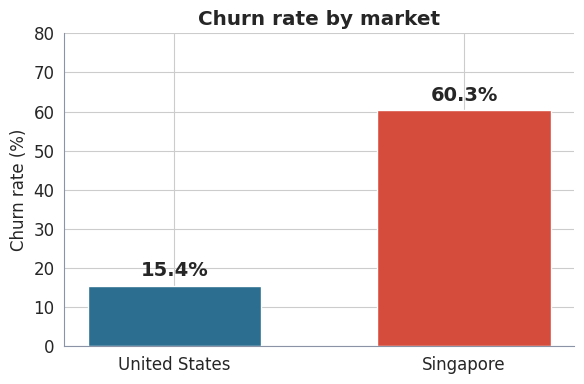

In [23]:
fig, ax = plt.subplots(figsize=(6, 4))
rate = df.groupby('market')['churned'].mean().mul(100).loc[['United States', 'Singapore']]
bars = ax.bar(rate.index, rate.values, color=[C_US, C_SG], width=.6)
ax.bar_label(bars, fmt='%.1f%%', fontweight='bold', fontsize=14, padding=4)
ax.set(ylabel='Churn rate (%)', ylim=(0, 80), title='Churn rate by market')
plt.savefig('viz_01_churn_by_market.png', dpi=150)
plt.show()

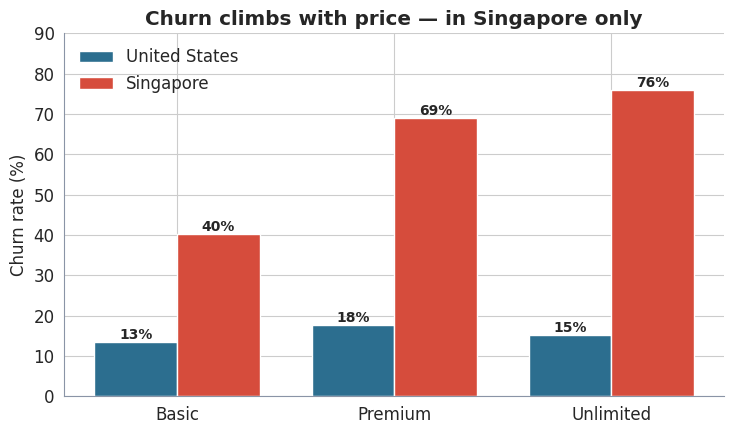

In [24]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
cr = df.groupby(['market', 'subscriber_type'])['churned'].mean().mul(100)
x = np.arange(3); w = .38
for i, (mkt, col) in enumerate([('United States', C_US), ('Singapore', C_SG)]):
    vals = [cr[mkt, p] for p in PLAN_ORDER]
    b = ax.bar(x + (i - .5) * w, vals, w, label=mkt, color=col)
    ax.bar_label(b, fmt='%.0f%%', fontweight='bold', fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(PLAN_LABELS)
ax.set(ylabel='Churn rate (%)', ylim=(0, 90), title='Churn climbs with price — in Singapore only')
ax.legend(frameon=False)
plt.savefig('viz_02_churn_by_plan.png', dpi=150)
plt.show()

churn rates across different subscriber types (Basic, Premium, Unlimited) for both the United States and Singapore

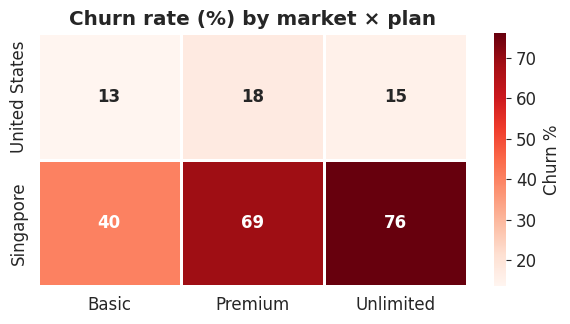

In [17]:
fig, ax = plt.subplots(figsize=(6, 3.4))
pivot = (df.pivot_table(index='market', columns='subscriber_type',
                        values='churned', aggfunc='mean').mul(100)
           .reindex(index=['United States', 'Singapore'], columns=PLAN_ORDER))
pivot.columns = PLAN_LABELS
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Reds', cbar_kws={'label': 'Churn %'},
            linewidths=1, linecolor='white', ax=ax, annot_kws={'fontweight': 'bold'})
ax.set(title='Churn rate (%) by market × plan', xlabel='', ylabel='')
plt.savefig('viz_03_churn_heatmap.png', dpi=150)
plt.show()


## 7 · Singapore drill-down — test the suspects

Right test per data type: **Mann–Whitney U** (+ **Cohen's d**) for numeric, **chi-square** for
plan. Effect sizes guard against calling trivial differences "significant".

**Mann–Whitney U Test**
Question it answers
Is there a statistically significant difference between the two groups?
The two groups are:

stay → customers who are still subscribed (churned = 0)
leave → customers who have churned (churned = 1)

**Why use Mann–Whitney U instead of a t-test?**

Because Mann–Whitney U:
1. Does not require the data to be normally distributed.
2. Is more robust when the data contains outliers or is skewed.

**Cohen's d**

Once we know that a difference exists, we ask another question:
How large is the difference?
This is what Cohen's d measures.

In [19]:
sg = df[df.country_name == 'singapore']
def cohens_d(a, b):
    pooled = np.sqrt(((len(a)-1)*a.std()**2 + (len(b)-1)*b.std()**2)/(len(a)+len(b)-2))
    return (a.mean()-b.mean())/pooled

for col in ['age','num_streams']:
    stay, leave = sg.loc[sg.churned==0, col], sg.loc[sg.churned==1, col]
    _, pv = stats.mannwhitneyu(stay, leave)
    print(f"{col:12s}: stay μ={stay.mean():.2f}  leave μ={leave.mean():.2f}  p={pv:.3f}  d={cohens_d(stay,leave):+.2f}")

_, pp, _, _ = stats.chi2_contingency(pd.crosstab(sg['subscriber_type'], sg['churned']))
print(f"\nplan tier: chi-square p={pp:.4f}")
print((sg.groupby('subscriber_type')['churned'].mean()*100).round(1))

age         : stay μ=26.74  leave μ=27.36  p=0.347  d=-0.07
num_streams : stay μ=15.63  leave μ=14.95  p=0.183  d=+0.14

plan tier: chi-square p=0.0000
subscriber_type
aavail_basic        40.4
aavail_premium      68.9
aavail_unlimited    76.0
Name: churned, dtype: float64


**Age → ruled out** (p≈0.35, d≈−0.07). **Engagement → ruled out** (p≈0.18, d≈0.14).
**Plan tier → confirmed** (p<0.001): Basic 40% → Premium 69% → Unlimited 76%.

## 8 · Interpretable model — logistic regression (odds ratios)

Isolates each factor's *independent* effect (cross-tabs can be confounded). Coefficients are
exponentiated into **odds ratios**: OR>1 raises churn odds.

In [20]:
X = pd.DataFrame({
    'is_singapore':   (df.country_name=='singapore').astype(int),
    'age':            df['age'],
    'num_streams':    df['num_streams'],
    'plan_premium':   (df.subscriber_type=='aavail_premium').astype(int),
    'plan_unlimited': (df.subscriber_type=='aavail_unlimited').astype(int)})
logit = sm.Logit(df['churned'], sm.add_constant(X)).fit(disp=0)
OR, CI = np.exp(logit.params), np.exp(logit.conf_int())
print(pd.DataFrame({'odds_ratio':OR.round(2),'CI_low':CI[0].round(2),
                    'CI_high':CI[1].round(2),'p':logit.pvalues.round(4)}).drop('const'))
print(f"\nPseudo R2 = {logit.prsquared:.3f}")

                odds_ratio  CI_low  CI_high       p
is_singapore          9.69    6.81    13.78  0.0000
age                   1.00    0.98     1.02  0.9673
num_streams           1.02    0.98     1.06  0.2788
plan_premium          2.16    1.47     3.19  0.0001
plan_unlimited        2.27    1.53     3.37  0.0000

Pseudo R2 = 0.183


Singapore ×**9.7** odds; Premium/Unlimited ≈ **2×**; age & streams not significant once
market and plan are controlled — confirming Step 7.

After considering all predictors simultaneously, country (Singapore) and subscription plan (Premium and Unlimited) are the strongest factors associated with customer churn. In contrast, age and number of streams do not have statistically significant effects in this model.

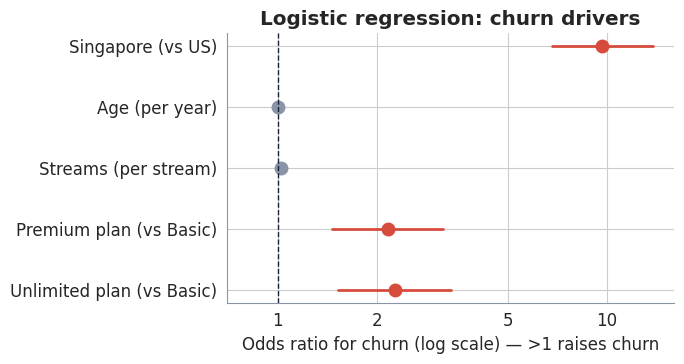

In [25]:
import statsmodels.api as sm
X = pd.DataFrame({
    'Singapore (vs US)':        (df.country_name == 'singapore').astype(int),
    'Age (per year)':           df['age'],
    'Streams (per stream)':     df['num_streams'],
    'Premium plan (vs Basic)':  (df.subscriber_type == 'aavail_premium').astype(int),
    'Unlimited plan (vs Basic)':(df.subscriber_type == 'aavail_unlimited').astype(int)})
m = sm.Logit(df['churned'], sm.add_constant(X)).fit(disp=0)
OR, CI = np.exp(m.params), np.exp(m.conf_int())
names = list(X.columns); y = np.arange(len(names))[::-1]

fig, ax = plt.subplots(figsize=(7, 3.8))
for yi, n in zip(y, names):
    c = C_SG if m.pvalues[n] < .05 else MUT
    ax.plot([CI.loc[n, 0], CI.loc[n, 1]], [yi, yi], color=c, lw=2)
    ax.plot(OR[n], yi, 'o', color=c, ms=9)
ax.axvline(1, color=INK, ls='--', lw=1)
ax.set(yticks=y, xscale='log', xlim=(0.7, 16),
       xlabel='Odds ratio for churn (log scale) — >1 raises churn',
       title='Logistic regression: churn drivers')
ax.set_yticklabels(names); ax.set_xticks([1, 2, 5, 10]); ax.set_xticklabels(['1', '2', '5', '10'])
plt.savefig('viz_07_odds_ratios.png', dpi=150)
plt.show()

## 9 · Predictive model — random forest

Non-linear cross-check: **5-fold CV ROC-AUC** (is churn predictable?) + **permutation
importance** (which features matter, model-agnostically).

In [21]:
rf = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42)
auc = cross_val_score(rf, X, df['churned'], cv=5, scoring='roc_auc')
print(f"5-fold ROC-AUC = {auc.mean():.3f} ± {auc.std():.3f}")
rf.fit(X, df['churned'])
imp = permutation_importance(rf, X, df['churned'], n_repeats=20, random_state=42)
for i in imp.importances_mean.argsort()[::-1]:
    print(f"  {X.columns[i]:15s} {imp.importances_mean[i]:.3f}")

5-fold ROC-AUC = 0.743 ± 0.039
  is_singapore    0.157
  plan_unlimited  0.044
  num_streams     0.036
  age             0.036
  plan_premium    0.034


ROC-AUC ≈ 0.74; top signals = **market** then **Unlimited plan** — same as the regression.
Two methods agreeing = strong evidence.

Logistic Regression → explains the relationship between predictors and churn (interpretation).
Random Forest → focuses on prediction, then identifies which variables are most important for making those predictions.

**Results**
1. Country is the strongest predictor of customer churn.
2. Customers with the Unlimited plan provide useful information for predicting churn.
3. num_streams: This feature has a relatively small contribution to prediction.
4. Age also has a small contribution.
Unlike Logistic Regression, Random Forest can capture nonlinear relationships, so even variables that are not statistically significant may still provide some predictive value.
5. Premium plan also contributes to prediction, although slightly less than Unlimited.


The Random Forest model achieves good predictive performance (ROC-AUC = 0.743). Among all variables, country (Singapore) is the most influential predictor of churn, while subscription plan also contributes meaningfully. Age and number of streams have relatively smaller predictive importance.

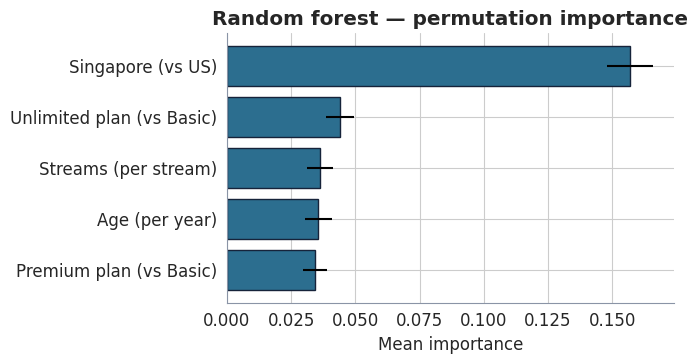

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
rf = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42).fit(X, df['churned'])
imp = permutation_importance(rf, X, df['churned'], n_repeats=20, random_state=42)
order = imp.importances_mean.argsort()

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.barh(np.array(names)[order], imp.importances_mean[order],
        xerr=imp.importances_std[order], color=C_US, edgecolor=INK)
ax.set(title='Random forest — permutation importance', xlabel='Mean importance')
plt.savefig('viz_08_rf_importance.png', dpi=150)
plt.show()

## 10 · Segmentation — K-means

*Who* is at risk. Standardize features, cluster into 4 groups, profile by market share and
churn.

In [ ]:
feat = pd.DataFrame({'age':df.age, 'num_streams':df.num_streams,
    'is_singapore':(df.country_name=='singapore').astype(int),
    'plan_rank':df.subscriber_type.map({'aavail_basic':0,'aavail_premium':1,'aavail_unlimited':2})})
df['segment'] = KMeans(4, random_state=42, n_init=10).fit_predict(StandardScaler().fit_transform(feat))
print(df.groupby('segment').agg(size=('customer_id','size'),
    pct_singapore=('country_name', lambda s:(s=='singapore').mean()*100),
    mean_age=('age','mean'), mean_streams=('num_streams','mean'),
    churn_rate=('churned', lambda s:s.mean()*100)).round(1).sort_values('churn_rate', ascending=False))

One ~97%-Singapore segment carries ~58% churn — the concrete target for intervention.

The high-churn segment should be targeted with more attractive promotions, personalized offers, and loyalty rewards to encourage customers to remain subscribed. Meanwhile, customers in the low-churn segments can receive regular engagement campaigns and smaller incentives to maintain their loyalty and further reduce churn.

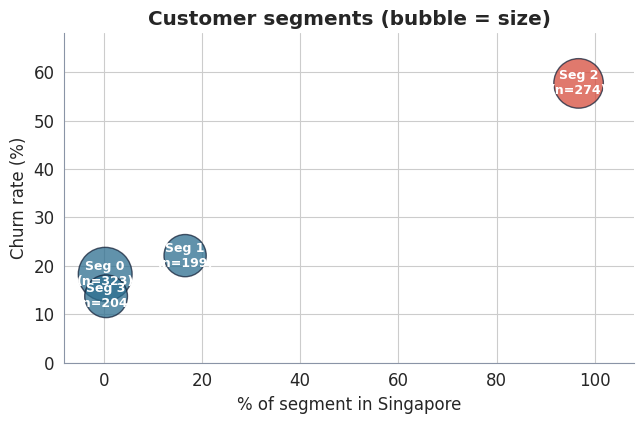

In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
feat = pd.DataFrame({'age': df.age, 'num_streams': df.num_streams,
    'is_sg': (df.country_name == 'singapore').astype(int),
    'plan': df.subscriber_type.map({'aavail_basic': 0, 'aavail_premium': 1, 'aavail_unlimited': 2})})
df['segment'] = KMeans(4, random_state=42, n_init=10).fit_predict(StandardScaler().fit_transform(feat))
g = df.groupby('segment').agg(n=('customer_id', 'size'),
        sg=('country_name', lambda s: (s == 'singapore').mean() * 100),
        churn=('churned', lambda s: s.mean() * 100))

fig, ax = plt.subplots(figsize=(6.6, 4.4))
ax.scatter(g['sg'], g['churn'], s=g['n'] / g['n'].max() * 1500,
           c=[C_SG if v > 50 else C_US for v in g['sg']], alpha=.75, edgecolor=INK, lw=1)
for i, r in g.iterrows():
    ax.annotate(f"Seg {i}\n(n={int(r['n'])})", (r['sg'], r['churn']),
                ha='center', va='center', color='white', fontweight='bold', fontsize=9)
ax.set(xlabel='% of segment in Singapore', ylabel='Churn rate (%)',
       xlim=(-8, 108), ylim=(0, 68), title='Customer segments (bubble = size)')
plt.savefig('viz_10_segments.png', dpi=150)
plt.show()



## 11 · Findings, caveats & next steps

**Findings**
- Singapore churns ~4× the US; market alone multiplies churn odds ~9.7×.
- Driver is **plan tier, not age or engagement**: churn rises with price in Singapore
  (Basic 40% → Premium 69% → Unlimited 76%), a pattern absent in the US.
- Logistic regression and random forest independently rank **market** and **premium/unlimited
  plans** as the dominant signals.
- A ~97%-Singapore segment concentrates the risk (~58% churn).

**Interpretation.** A **price–value mismatch in Singapore's premium tiers** — not a content or
usability problem, since engagement is healthy.

**Next steps**
1. A/B test pricing/packaging on Singapore Premium & Unlimited.
2. Survey churned Singapore premium customers for the *why*.
3. Instrument timestamped churn to replace the snapshot proxy.

**Caveats.** Snapshot churn proxy (no time dimension); a few non-subscribers carry a plan
label (kept as-is); ROC-AUC ~0.74 means much — not all — of churn is explained; richer data
(tenure, price paid, engagement over time) would sharpen the model.

In [38]:
# @title
!jupyter notebook --version

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
6.5.7
